In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import numpy as np
import os
import pickle

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

In [2]:
with open('res_a.pkl', 'rb') as f:
    res_a = pickle.load(f)
with open('res_t.pkl', 'rb') as f:
    res_t = pickle.load(f)    

In [3]:
df = pd.DataFrame(columns=['action_mode', 'tg_threshold', 'water_tank_size', 'urbac'])
outputpath='../data/water_tank_eval/'
for f in os.listdir(outputpath):
    f1 = outputpath + f
    ds = xr.open_dataset(f1)['URBAN_AC'].sel(column=1,
                                             time = slice('2010', '2019')
                                             ).sum(dim='time').values /10*0.5/1000*500*500*3.14159/1000*0.75/3.6
    
    exp0 = float(f.split('_')[2])
    exp1 = float(f.split('_')[3])
    exp2 = float(f.split('_')[4].split('.nc')[0])
    ds = float(ds)
    df = pd.concat([df, pd.DataFrame({'action_mode': [exp0], 'tg_threshold': [exp1], 'water_tank_size': [exp2], 'urbac': [ds]})])

In [4]:
city = "JP-Yoy"
surf = "../data/URBAN_PLUMBER/input_files/{city}/surfdata_1x1_{city}_detailed_simyr2000_c230710.nc"
surf = xr.open_dataset(surf.format(city=city))
WTLUNIT_ROOF = surf["WTLUNIT_ROOF"].values.flatten()[2]
WTROAD_PERV = surf["WTROAD_PERV"].values.flatten()[2]

ds_list = []
ds_list_jja = []
p_dict = {
    'action_mode': [],
    'tg_threshold': [], 
    'water_tank_size': [],
}
outputpath='../data/water_tank_eval_0/'
ref_dsf = '/home/junjie/github/UrbSprIrr/data/workdir/outputfolder/lnd/hist/roofsp_raw.clm2.h0.2006-01-01-00000.nc'
ref_ds = xr.open_dataset(ref_dsf).sel(column=1,time = slice('2010', '2019'))
_ref_ds = xr.open_dataset(ref_dsf).sel(time = slice('2010', '2019')) 
ref_ds['QOVER'] = _ref_ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ref_ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ref_ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

ref_ds['time'] = ref_ds['time'].dt.round('min') + np.timedelta64(9, 'h')    
#ref_ds_jja = ref_ds.sel(time=ref_ds['time.season']=='JJA')
ref_ds_jja = ref_ds.sel(time=(ref_ds['time.month']>=6) & (ref_ds['time.month']<=9))
for f in os.listdir(outputpath):
    f1 = outputpath + f
    ds = xr.open_dataset(f1).sel(column=1,time = slice('2010', '2019'))    
    _ds = xr.open_dataset(f1).sel(time = slice('2010', '2019')) 
    ds['QOVER'] = _ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

    ds['time'] = ds['time'].dt.round('min') + np.timedelta64(9, 'h')
    exp0 = float(f.split('_')[2])
    exp1 = float(f.split('_')[3])
    exp2 = float(f.split('_')[4].split('.nc')[0])
    
    ds_list.append(ds)
    #6，7，8，9
    ds_list_jja.append(ds.sel(time=(ds['time.month']>=6) & (ds['time.month']<=9)))
    p_dict['action_mode'].append(exp0)
    p_dict['tg_threshold'].append(exp1)
    p_dict['water_tank_size'].append(exp2)
    
rwts_dict = {
    p_dict['water_tank_size'][i]: ds_list[i] for i in range(len(ds_list))
}
rwts_dict_jja = {
    p_dict['water_tank_size'][i]: ds_list_jja[i] for i in range(len(ds_list))
}

def plot_profile_exp(rwts_dict, ref_ds, var, timetype, ax):
    colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)+2))
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    i = 0
    
    #if var in ['TG', 'TSA']:
    #    (ref_ds[var].groupby(f'time.{timetype}').mean('time')-273.15).plot(ax=ax, label='Reference', color='#E02927')
    #elif var in ['QOVER']:
    #    qover = ref_ds[var]*3600
    #    (qover.groupby(f'time.{timetype}').mean('time')).plot(ax=ax, label='Reference', color='#E02927')
    #else:
    #    ref_ds[var].groupby(f'time.{timetype}').mean('time').plot(ax=ax, label='Reference', color='#E02927')
    for w in rwts:
        if var in ['TG', 'TSA']:
            (rwts_dict[w][var].groupby(f'time.{timetype}').mean('time')-273.15).plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        elif var in ['QOVER', 'QOUT_WATER_TANK', 'QIN_WATER_TANK']:
            qover = rwts_dict[w][var]*3600
            (qover.groupby(f'time.{timetype}').mean('time')).plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        else:
            rwts_dict[w][var].groupby(f'time.{timetype}').mean('time').plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        i += 1

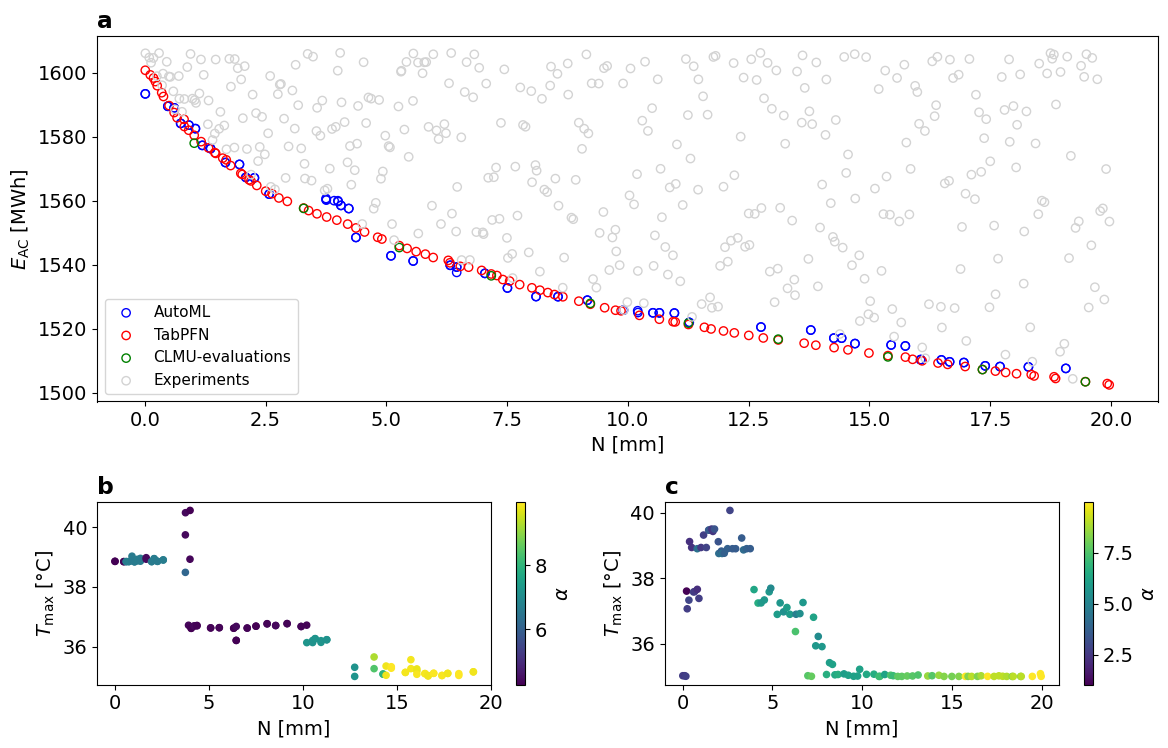

In [14]:
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 1, 1])
df_exps = pd.read_csv('/home/junjie/github/UrbSprIrr/src_water_tank/water_tank_exps.csv')
def plot_resX(res,ax=None):
    solution = res.X
    solution = pd.DataFrame(solution, columns=['SI', 'T$_{\\mathrm{g}}$ threshold [°C]', 'RWT size [mm]']).sort_values(by=['RWT size [mm]'])
    if ax is None:
        return solution
    else:
        solution.plot(x='RWT size [mm]', y='T$_{\\mathrm{g}}$ threshold [°C]', kind='scatter', c='SI', colormap='viridis',
                      colorbar=True,ax=ax)
        cbar = ax.collections[0].colorbar
        cbar.set_label('$\\alpha$')

ax1 = fig.add_subplot(gs[0, :]) 
#ax1.scatter(res_a.F[:,0], res_a.F[:,1], label='AutoML', color='blue', facecolors='none', edgecolors='blue')
#ax1.scatter(res_t.F[:,0], res_t.F[:,1], label='TabPFN', color='red', facecolors='none', edgecolors='red')
#ax1.scatter(df['urbac'], df['water_tank_size'], label='CLMU-evaluations', color='green', facecolors='none', edgecolors='green')
ax1.scatter(res_a.F[:,1], res_a.F[:,0], label='AutoML', color='blue', facecolors='none', edgecolors='blue')
ax1.scatter(res_t.F[:,1], res_t.F[:,0], label='TabPFN', color='red', facecolors='none', edgecolors='red')
ax1.scatter(df['water_tank_size'], df['urbac'], label='CLMU-evaluations', color='green', facecolors='none', edgecolors='green')
ax1.scatter(df_exps['water_tank_size'], df_exps['urbac'], label='Experiments', color='orange', facecolors='none', edgecolors='lightgray')


#ax1.set_xlabel('$E_{\\mathrm{AC}}$ [MWh]')
#ax1.set_ylabel('RWT size [mm]')
ax1.set_xlabel('N [mm]')
ax1.set_ylabel('$E_{\\mathrm{AC}}$ [MWh]')
ax1.legend(frameon=True, fontsize=11)
ax1.set_title('a', loc='left', fontweight='bold')


ax2 = fig.add_subplot(gs[1, 0])
plot_resX(res_a, ax2)
ax2.set_title('b', loc='left', fontweight='bold')
ax2.set_xlabel('N [mm]')
ax2.set_ylabel('$T_{\\mathrm{max}}$ [°C]')
ax2.legend(frameon=False)
ax3 = fig.add_subplot(gs[1, 1]) 
plot_resX(res_t, ax3)
ax3.set_xlabel('N [mm]')
ax3.set_ylabel('$T_{\\mathrm{max}}$ [°C]')
ax3.set_title('c', loc='left', fontweight='bold')
ax3.legend(frameon=False)

plt.tight_layout()
plt.savefig('../data/figs/water_tank_moo.pdf', dpi=300, bbox_inches='tight')
plt.show()

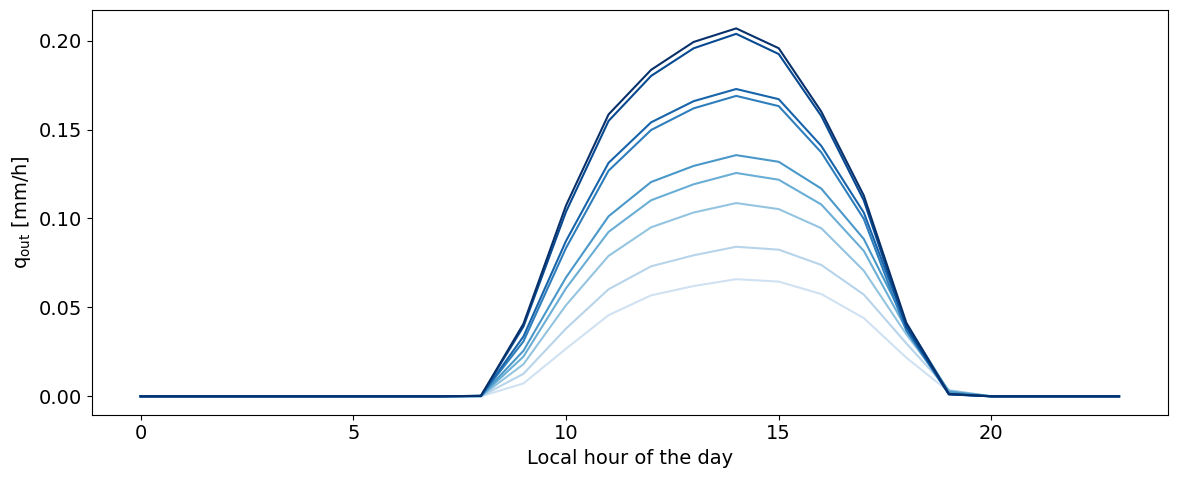

In [6]:
fig = plt.figure(figsize=(12, 5))

#ax = fig.add_subplot(1, 1, 1)
#colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)))
## 计算空箱率
#rates = [
#    (rwts_dict[w]['WATER_TANK'] > 0.001).sum().item() / rwts_dict[w]['WATER_TANK'].size for w in sorted(rwts_dict.keys())
#]
#ac_reduction = [
#    rwts_dict[w]['URBAN_AC'].sel(time = slice('2010', '2019')).sum(dim='time').values for w in sorted(rwts_dict.keys())
#]
#
#ax.plot(sorted(rwts_dict.keys()), ac_reduction, marker='s', color='b')
#ax.set_xlabel('RWT size [mm]')
#ax.set_ylabel('$E_{\\mathrm{AC}}$ [MWh]')
#ax = ax.twinx()
#ax.plot(sorted(rwts_dict.keys()), rates, marker='o', color='orange')
#ax.set_xlabel('RWT size [mm]')
#ax.set_ylabel('Non-empty tank rate', color='orange')
#
#ax.set_title('a', loc='left', fontweight='bold')


ax2 = fig.add_subplot(1, 1, 1)

vas = ['QOUT_WATER_TANK', 'QIN_WATER_TANK', 'WATER_TANK']
#titles = ['b']
ylabels = ['q$\mathrm{_{out}}$ [mm/h]', 'Q$\mathrm{_{in}}$[mm/h]', 'Water in RWT [mm]']
i = 0
for ax in [ax2]:
    plot_profile_exp(rwts_dict_jja, ref_ds_jja, vas[i], 'hour', ax)
    #ax.set_title(titles[i], loc='left', fontweight='bold')
    ax.set_ylabel(ylabels[i])
    ax.set_xlabel('Local hour of the day')
    
    i += 1
plt.tight_layout()
plt.savefig('../data/figs/water_tank_profiles.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
#ig, ax = plt.subplots(1, 2, figsize=(12, 5))
#lot_resX(res_a, ax=ax[0])
#x[0].set_title('AutoML', fontweight='bold')
#lot_resX(res_t, ax=ax[1])
#x[1].set_title('TabPFN', fontweight='bold')
#lt.tight_layout()  
#lt.show()

In [8]:
import numpy as np

idx_500 = np.abs(res_t.F[:,0] - 500).argmin()
idx_300 = np.abs(res_t.F[:,0] - 300).argmin()

closest_500 = res_t.F[idx_500, 1]
closest_300 = res_t.F[idx_300, 1]

value_500 = res_t.F[idx_500, 0]
value_300 = res_t.F[idx_300, 0]

max_value = res_t.F[:, 0].max()
min_value = res_t.F[:, 0].min()
print(f"res_t.F[:,0]最大值={max_value}")
print(f"res_t.F[:,0]最小值={min_value}")

closest_mid = res_t.F[np.abs(res_t.F[:,0] - (max_value + min_value)/2).argmin(), 1]
value_mid = res_t.F[np.abs(res_t.F[:,0] - (max_value + min_value)/2).argmin(), 0]

print(f"res_t.F[:,0]最接近500时，res_t.F[:,0]={value_500}，res_t.F[:,1]={closest_500}")
print(f"res_t.F[:,0]最接近300时，res_t.F[:,0]={value_300}，res_t.F[:,1]={closest_300}")
print(f"res_t.F[:,0]最接近中间值时，res_t.F[:,0]={value_mid}，res_t.F[:,1]={closest_mid}")

res_t.F[:,0]最大值=1600.764892578125
res_t.F[:,0]最小值=1502.454345703125
res_t.F[:,0]最接近500时，res_t.F[:,0]=1502.454345703125，res_t.F[:,1]=19.965297023167544
res_t.F[:,0]最接近300时，res_t.F[:,0]=1502.454345703125，res_t.F[:,1]=19.965297023167544
res_t.F[:,0]最接近中间值时，res_t.F[:,0]=1551.494384765625，res_t.F[:,1]=4.370760610933006


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import os
import pickle


with open('res_a.pkl', 'rb') as f:
    res_a = pickle.load(f)
with open('res_t.pkl', 'rb') as f:
    res_t = pickle.load(f)    

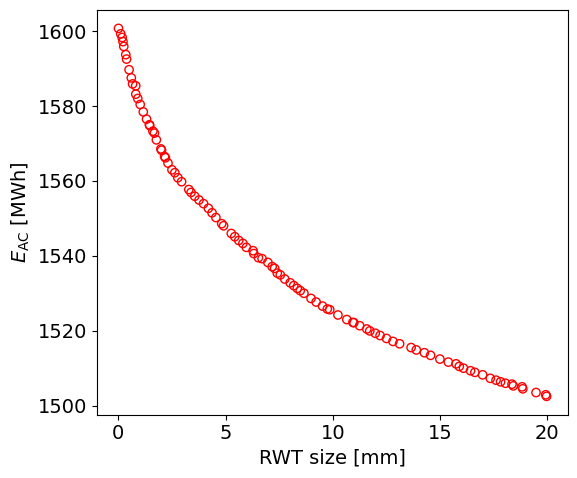

In [10]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.scatter(res_t.F[:,1], res_t.F[:,0],  label='TabPFN', color='red', facecolors='none', edgecolors='red')
ax.set_xlabel('RWT size [mm]')
ax.set_ylabel('$E_{\\mathrm{AC}}$ [MWh]')

plt.tight_layout()
#plt.savefig('../data/figs/water_tank_moo_t.pdf', dpi=300, bbox_inches='tight')